<a href="https://colab.research.google.com/github/priyanka0178885547/DL-lab/blob/main/week12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

PCA with AE

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.0596 - val_loss: 0.0326
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0264 - val_loss: 0.0209
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0182 - val_loss: 0.0152
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0137 - val_loss: 0.0117
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0107 - val_loss: 0.0093
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0087 - val_loss: 0.0077
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0074 - val_loss: 0.0066
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0064 - val_loss: 0.0059
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0058 - val_loss: 0.0053
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0053 - val_loss: 0.0050
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


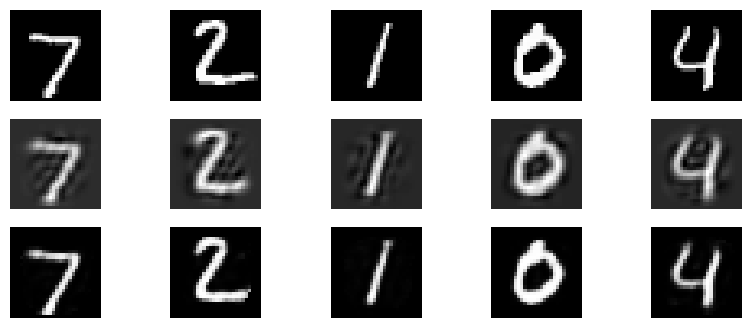

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.decomposition import PCA
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

pca = PCA(n_components=64)
x_pca = pca.fit_transform(x_test)
x_pca_recon = pca.inverse_transform(x_pca)

input_img = layers.Input(shape=(784,))
encoded = layers.Dense(64, activation='relu')(input_img)
decoded = layers.Dense(784, activation='sigmoid')(encoded)

autoencoder = models.Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

autoencoder.fit(x_train, x_train, epochs=10, batch_size=256, validation_data=(x_test, x_test))

x_ae_recon = autoencoder.predict(x_test)

plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(3,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(3,5,i+6)
    plt.imshow(x_pca_recon[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(3,5,i+11)
    plt.imshow(x_ae_recon[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

In [ ]:
Sparse AE and Contractive AE

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 0.1661 - val_loss: 0.1007
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0912 - val_loss: 0.0837
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0791 - val_loss: 0.0759
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0736 - val_loss: 0.0720
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0706 - val_loss: 0.0695
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0685 - val_loss: 0.0678
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0671 - val_loss: 0.0664
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0659 - val_loss: 0.0654
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0650 - val_loss: 0.0646
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0642 - val_loss: 0.0639
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


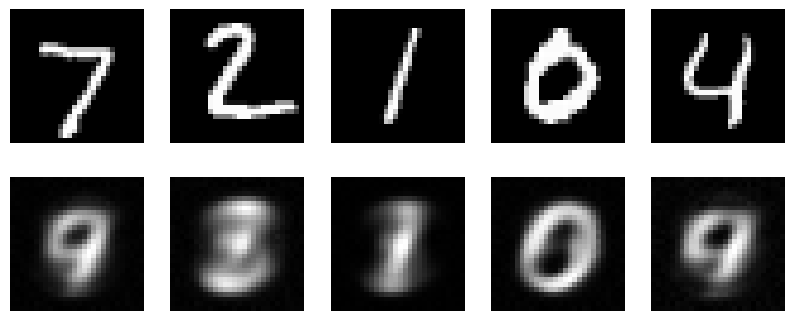

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

input_img = layers.Input(shape=(784,))
encoded = layers.Dense(64, activation='relu', activity_regularizer=regularizers.l1(1e-5))(input_img)
decoded = layers.Dense(784, activation='sigmoid')(encoded)

model = models.Model(input_img, decoded)
model.compile(optimizer='adam', loss='mse')

model.fit(x_train, x_train, epochs=10, batch_size=256, validation_data=(x_test, x_test))

reconstructed = model.predict(x_test)

plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(2,5,i+6)
    plt.imshow(reconstructed[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

Epoch: 1 Loss: 0.06454619
Epoch: 2 Loss: 0.06285961
Epoch: 3 Loss: 0.05860263
Epoch: 4 Loss: 0.051595718
Epoch: 5 Loss: 0.045948938
Epoch: 6 Loss: 0.042111367
Epoch: 7 Loss: 0.039267566
Epoch: 8 Loss: 0.03690488
Epoch: 9 Loss: 0.03486354
Epoch: 10 Loss: 0.033128623
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


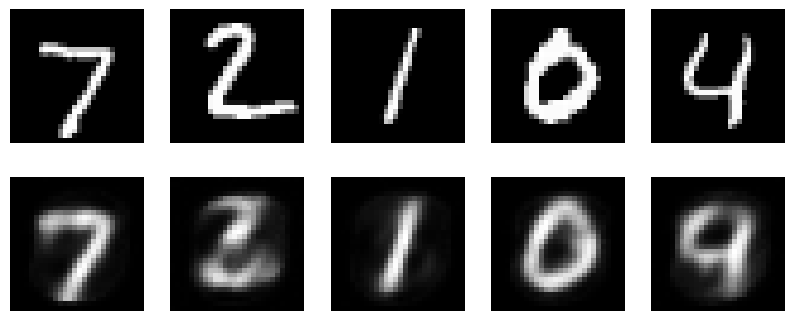

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)

input_img = layers.Input(shape=(784,))
encoder = layers.Dense(64, activation='sigmoid')
decoder = layers.Dense(784, activation='sigmoid')

encoded = encoder(input_img)
decoded = decoder(encoded)

model = models.Model(input_img, decoded)

optimizer = tf.keras.optimizers.Adam()
lam = 1e-4

for epoch in range(10):
    for batch in tf.data.Dataset.from_tensor_slices(x_train).batch(256):
        batch = tf.cast(batch, tf.float32)

        with tf.GradientTape() as tape:
            with tf.GradientTape() as tape2:
                tape2.watch(batch)
                encoded_out = encoder(batch)

            decoded_out = decoder(encoded_out)

            mse = tf.reduce_mean(tf.square(batch - decoded_out))

            grads = tape2.gradient(encoded_out, batch)
            contractive = lam * tf.reduce_mean(tf.square(grads))

            loss = mse + contractive

        gradients = tape.gradient(loss, model.trainable_weights)
        optimizer.apply_gradients(zip(gradients, model.trainable_weights))

    print("Epoch:", epoch+1, "Loss:", loss.numpy())

reconstructed = model.predict(x_test)

plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.axis('off')

    plt.subplot(2,5,i+6)
    plt.imshow(reconstructed[i].reshape(28,28), cmap='gray')
    plt.axis('off')

plt.show()

Next char

In [ ]:
import torch
import torch.nn as nn

text = "machine learning is amazing"
chars = sorted(list(set(text)))
c2i = {c:i for i,c in enumerate(chars)}
i2c = {i:c for c,i in c2i.items()}

data = [c2i[c] for c in text]

X = torch.tensor([data[:-1]])
Y = torch.tensor(data[1:])

embed = nn.Embedding(len(chars), 8)
rnn = nn.RNN(8, 16, batch_first=True)
fc = nn.Linear(16, len(chars))

opt = torch.optim.Adam(list(embed.parameters()) + list(rnn.parameters()) + list(fc.parameters()), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(300):
    out, _ = rnn(embed(X))
    out = fc(out)
    loss = loss_fn(out.view(-1, len(chars)), Y.view(-1))

    opt.zero_grad()
    loss.backward()
    opt.step()

test = "machine"
t = torch.tensor([[c2i[c] for c in test]])

out, _ = rnn(embed(t))
pred = fc(out)[0, -1]

print("Next char:", i2c[pred.argmax().item()])

Next char:  


Next word

In [ ]:
text = "machine learning is powerful machine learning is useful"
words = text.split()

vocab = list(set(words))
w2i = {w:i for i,w in enumerate(vocab)}
i2w = {i:w for w,i in w2i.items()}

data = [w2i[w] for w in words]
X = torch.tensor([data[:-1]])
Y = torch.tensor(data[1:])

embed = nn.Embedding(len(vocab), 8)
rnn = nn.RNN(8, 16, batch_first=True)
fc = nn.Linear(16, len(vocab))

opt = torch.optim.Adam(list(embed.parameters())+list(rnn.parameters())+list(fc.parameters()), lr=0.01)

for _ in range(200):
    out,_ = rnn(embed(X))
    loss = nn.CrossEntropyLoss()(fc(out).view(-1,len(vocab)), Y.view(-1))
    opt.zero_grad(); loss.backward(); opt.step()

test = ["machine","learning","is"]
t = torch.tensor([[w2i[w] for w in test]])
out,_ = rnn(embed(t))
pred = fc(out)[0,-1]
print("Next word:", i2w[pred.argmax().item()])

Next word: powerful


Next sentence

In [ ]:
import torch
import torch.nn as nn

text = "machine learning is amazing"
chars = sorted(list(set(text)))
c2i = {c:i for i,c in enumerate(chars)}
i2c = {i:c for c,i in c2i.items()}

data = [c2i[c] for c in text]

X = torch.tensor([data[:-1]])
Y = torch.tensor(data[1:])

embed = nn.Embedding(len(chars), 8)
rnn = nn.RNN(8, 16, batch_first=True)
fc = nn.Linear(16, len(chars))

opt = torch.optim.Adam(list(embed.parameters()) + list(rnn.parameters()) + list(fc.parameters()), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

for epoch in range(300):
    out, _ = rnn(embed(X))
    out = fc(out)
    loss = loss_fn(out.view(-1, len(chars)), Y.view(-1))

    opt.zero_grad()
    loss.backward()
    opt.step()

generated = "machine"

for _ in range(20):
    t = torch.tensor([[c2i[c] for c in generated]])
    out, _ = rnn(embed(t))
    pred = fc(out)[0, -1]
    next_char = i2c[pred.argmax().item()]
    generated += next_char

print("Generated text:", generated)

Generated text: machine learning is amazing


LSTM

In [ ]:
embed = nn.Embedding(len(vocab), 8)
lstm = nn.LSTM(8, 16, batch_first=True)
fc = nn.Linear(16, len(vocab))

opt = torch.optim.Adam(list(embed.parameters())+list(lstm.parameters())+list(fc.parameters()), lr=0.01)

for _ in range(200):
    out,_ = lstm(embed(X))
    loss = nn.CrossEntropyLoss()(fc(out).view(-1,len(vocab)), Y.view(-1))
    opt.zero_grad(); loss.backward(); opt.step()

out,_ = lstm(embed(t))
print("LSTM next word:", i2w[fc(out)[0,-1].argmax().item()])

LSTM next word: powerful


GRU

In [ ]:
embed = nn.Embedding(len(vocab), 8)
gru = nn.GRU(8, 16, batch_first=True)
fc = nn.Linear(16, len(vocab))

opt = torch.optim.Adam(list(embed.parameters())+list(gru.parameters())+list(fc.parameters()), lr=0.01)

for _ in range(200):
    out,_ = gru(embed(X))
    loss = nn.CrossEntropyLoss()(fc(out).view(-1,len(vocab)), Y.view(-1))
    opt.zero_grad(); loss.backward(); opt.step()

out,_ = gru(embed(t))
print("GRU next word:", i2w[fc(out)[0,-1].argmax().item()])

GRU next word: powerful


Encoder- Decoder



In [ ]:
pairs = [("hi","hello"), ("ml","ai")]

chars = list(set("<>" + "".join([x+y for x,y in pairs])))
c2i = {c:i for i,c in enumerate(chars)}
i2c = {i:c for c,i in c2i.items()}

def t(s): return torch.tensor([[c2i[c] for c in s]])

E = nn.Embedding(len(chars), 8)
L = nn.LSTM(8, 16, batch_first=True)
F = nn.Linear(16, len(chars))

opt = torch.optim.Adam(list(E.parameters())+list(L.parameters())+list(F.parameters()), lr=0.01)
loss_fn = nn.CrossEntropyLoss()

for _ in range(500):
    for x,y in pairs:
        _,(h,c) = L(E(t(x)))
        inp = t("<")
        loss = 0
        for ch in y:
            out,(h,c) = L(E(inp),(h,c))
            loss += loss_fn(F(out).view(1,-1), t(ch).view(-1))
            inp = t(ch)
        opt.zero_grad(); loss.backward(); opt.step()

_,(h,c) = L(E(t("ml")))
inp = t("<")
res = ""

for _ in range(6):
    out,(h,c) = L(E(inp),(h,c))
    p = F(out).argmax(2)
    res += i2c[p.item()]
    inp = p

print("Output:", res)

Output: aiielo


Attention Mechanism



In [ ]:
class Attention(nn.Module):
    def __init__(self):
        super().__init__()

    def forward(self, hidden, encoder_outputs):
        hidden = hidden.permute(1,0,2)
        scores = torch.bmm(hidden, encoder_outputs.transpose(1,2))
        weights = torch.softmax(scores, dim=2)
        context = torch.bmm(weights, encoder_outputs)
        return context, weights

att = Attention()

encoder_outputs = torch.rand(1,5,8)
hidden = torch.rand(1,1,8)

context, weights = att(hidden, encoder_outputs)

print("weights:", weights)
print("sum:", weights.sum())

weights: tensor([[[0.2489, 0.2443, 0.1403, 0.1881, 0.1784]]])
sum: tensor(1.0000)


In [ ]:
1
